In [1]:
# Uncomment if necessary

!pip install -q shap

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

MODEL_DIR = f"{PROJECT_DIR}/models"

FIGURE_DIR = f"{PROJECT_DIR}/figures"

RESULT_DIR = f"{PROJECT_DIR}/results"

In [5]:
TARGET = "dropout_label"

df = pd.read_csv(
    f"{PROJECT_DIR}/engineered_data.csv"
)

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.20,
    random_state=42
)

In [7]:
final_model = joblib.load(
    f"{MODEL_DIR}/engineered_lightgbm.pkl"
)

In [8]:
explainer = shap.TreeExplainer(final_model)

In [9]:
shap_values = explainer.shap_values(X_test)

In [10]:
explanation = explainer(X_test)

In [11]:
explanation = explainer(X_test)

In [12]:
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP|": np.abs(explanation.values).mean(axis=0)
})

importance = importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

importance.head(20)

,Feature,Mean |SHAP|
9,term_2_attendance,0.826233
15,average_exam_score,0.826203
33,family_income_level,0.551774
8,term_1_attendance,0.411226
10,term_3_attendance,0.356725
13,science_exam_score,0.281637
2,school_type,0.226950
0,school_code,0.144419
14,social_studies_exam_score,0.111440
36,class_participation,0.099459


In [13]:
importance.to_csv(
    f"{RESULT_DIR}/shap_feature_importance.csv",
    index=False
)

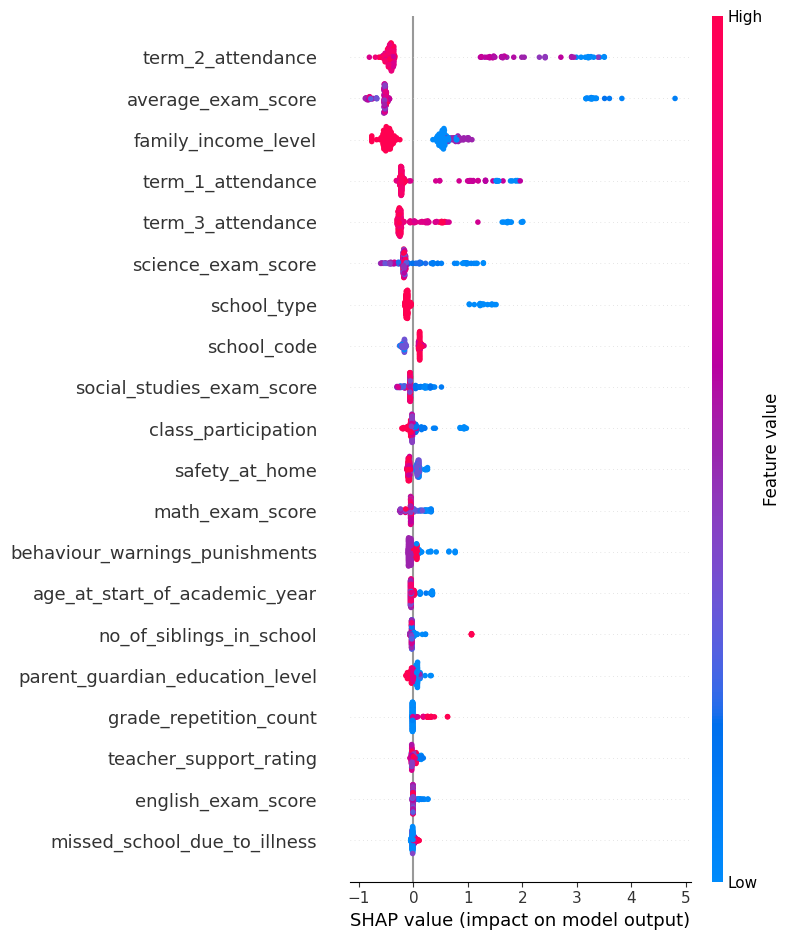

In [14]:
shap.summary_plot(
    explanation,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

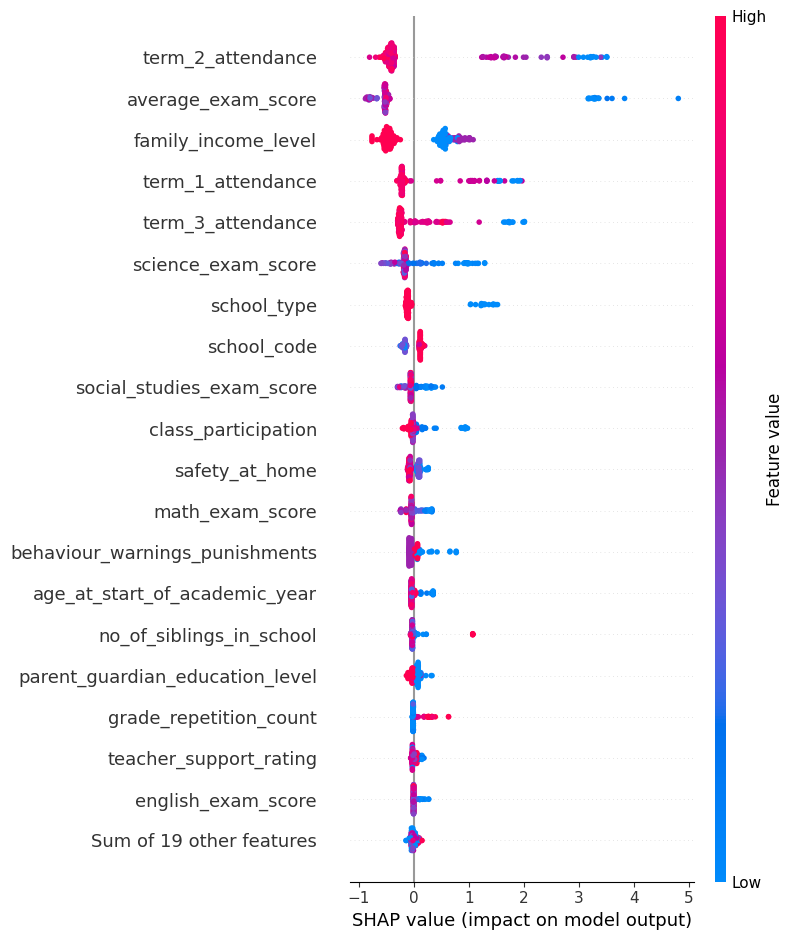

In [15]:
shap.plots.beeswarm(
    explanation,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

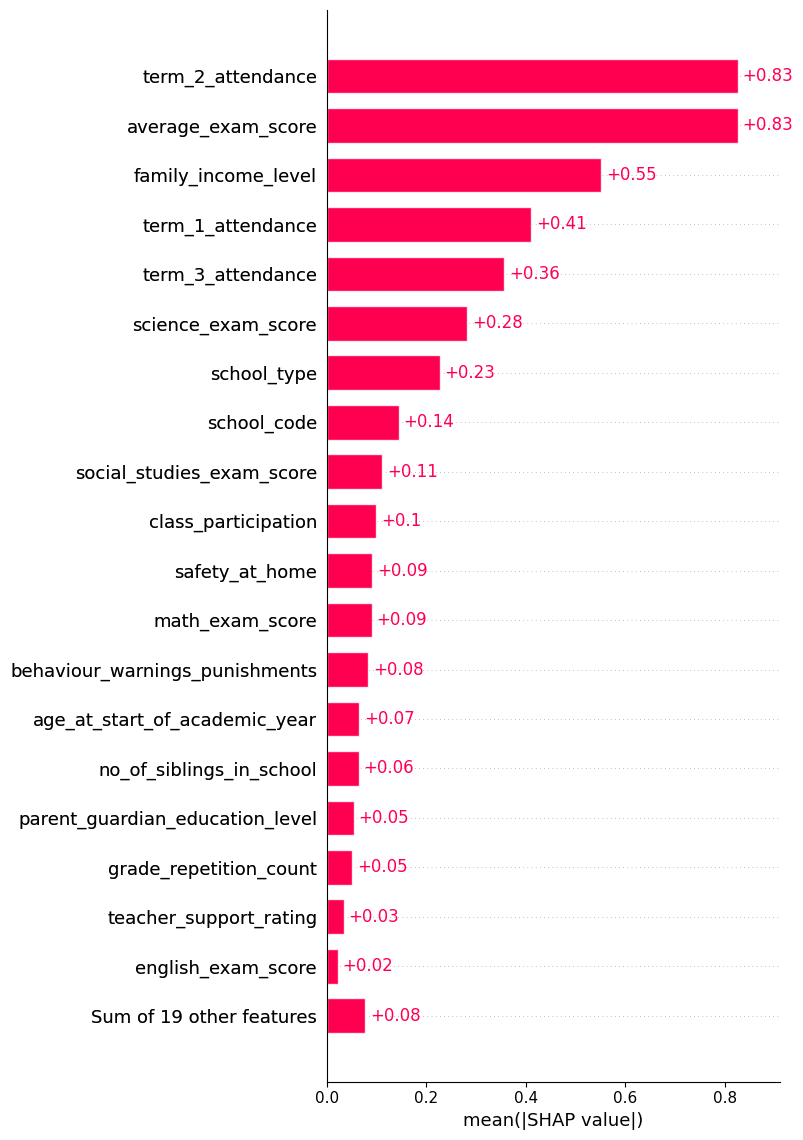

In [16]:
shap.plots.bar(
    explanation,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
top_features = importance["Feature"].head(5).tolist()

top_features

['term_2_attendance',
 'average_exam_score',
 'family_income_level',
 'term_1_attendance',
 'term_3_attendance']

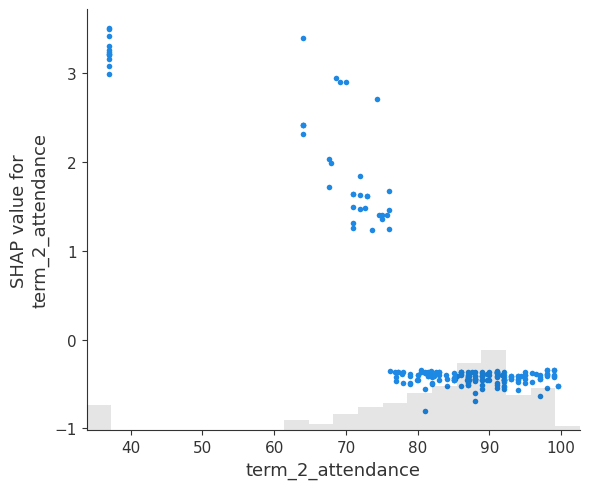

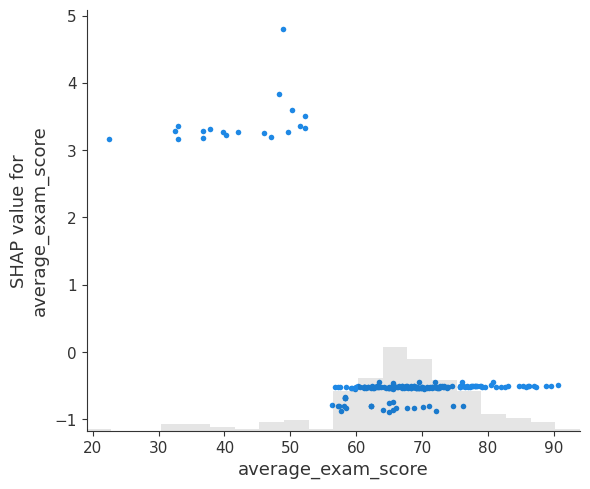

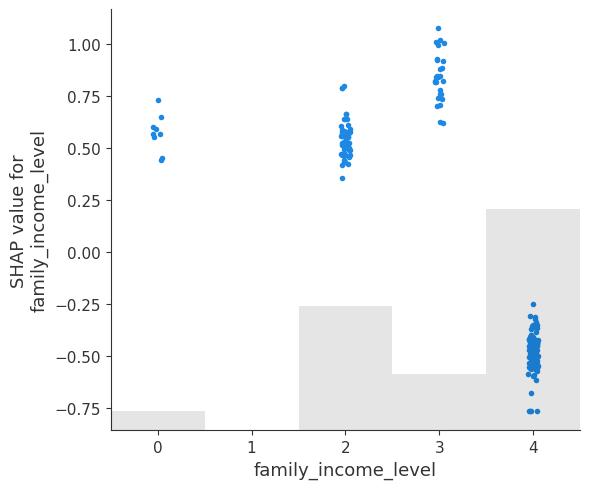

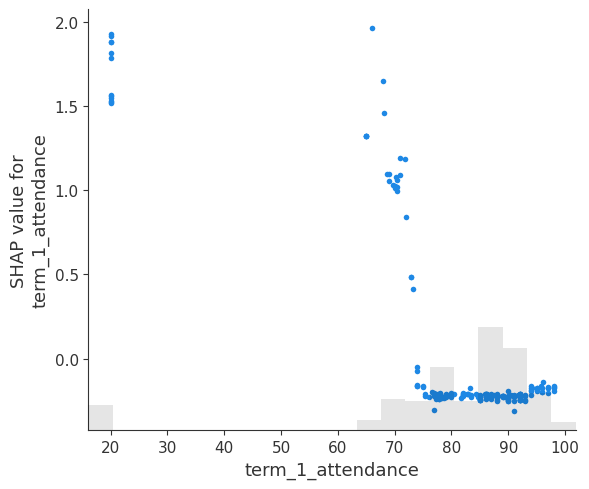

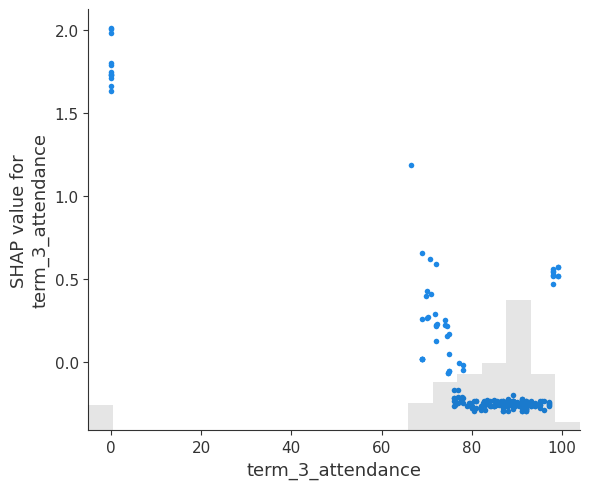

In [18]:
for feature in top_features:

    shap.plots.scatter(
        explanation[:, feature],
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        f"{FIGURE_DIR}/dependence_{feature}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

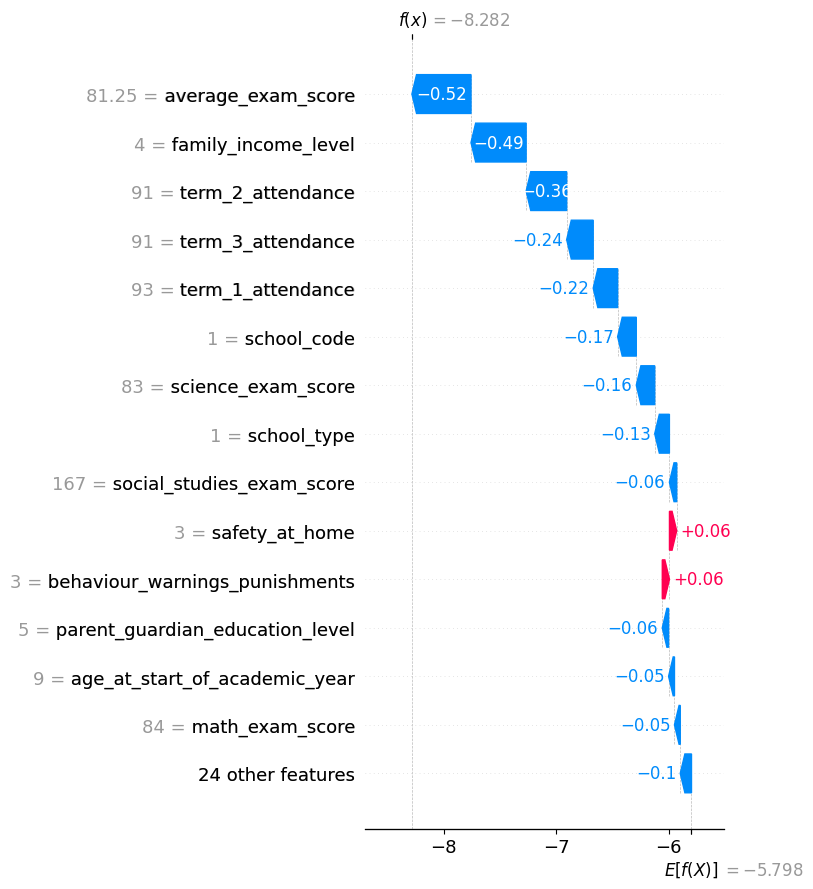

In [19]:
student = 0

shap.plots.waterfall(
    explanation[student],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/waterfall_student0.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
shap.initjs()

shap.plots.force(
    explanation[0]
)

In [21]:
students = [0, 5, 10]

for s in students:

    print("=" * 60)
    print(f"Student {s}")
    print("=" * 60)

    print("Actual :", y_test.iloc[s])
    print("Predicted Probability :",
          final_model.predict_proba(
              X_test.iloc[[s]]
          )[0,1])

Student 0
Actual : 0
Predicted Probability : 0.00025306732758933423
Student 5
Actual : 0
Predicted Probability : 0.0009456493553600801
Student 10
Actual : 0
Predicted Probability : 0.002750988189287897


In [22]:
print("=" * 60)
print("Top 20 Predictors of Student Dropout")
print("=" * 60)

display(importance.head(20))

Top 20 Predictors of Student Dropout


,Feature,Mean |SHAP|
9,term_2_attendance,0.826233
15,average_exam_score,0.826203
33,family_income_level,0.551774
8,term_1_attendance,0.411226
10,term_3_attendance,0.356725
13,science_exam_score,0.281637
2,school_type,0.226950
0,school_code,0.144419
14,social_studies_exam_score,0.111440
36,class_participation,0.099459


In [23]:
shap_interaction_values = explainer.shap_interaction_values(X_test)